In [4]:
import pandas as pd

In [5]:
import zstandard as zstd
import json
import io

file_path = "RS_2019-04.zst"

posts = []

with open(file_path, 'rb') as fh:
    dctx = zstd.ZstdDecompressor()
    stream_reader = dctx.stream_reader(fh)
    text_stream = io.TextIOWrapper(stream_reader, encoding='utf-8')

    for line in text_stream:
        try:
            post = json.loads(line)
            body = post.get("selftext", "").strip()
            
            # Skip if body is blank, deleted, or removed
            if not body or body == "[deleted]" or body == "[removed]":
                continue
            
            posts.append({
                "id": post.get("id"),
                "author": post.get("author"),
                "subreddit": post.get("subreddit"),
                "title": post.get("title", ""),
                "body": body,
                "score": post.get("score"),
                "num_comments": post.get("num_comments", 0),
                "created_utc": post.get("created_utc")
            })

            if len(posts) > 500000:
                break

        except:
            pass

df = pd.DataFrame(posts)

print(df.head())


       id             author     subreddit  \
0  b7um2n  FortniteStatusBot      FORTnITE   
1  b7um2w   ConservativeBrit        tories   
2  b7um30            Umbresp     dankmemes   
3  b7um3e            ranalog        analog   
4  b7um3f     philarunner962  trailrunning   

                                      title  \
0                   Daily Llama 31/Mar/2019   
1  Polls - Next Election - Honest Opinions.   
2                      🚂START YOUR ENGINES🚂   
3          Monthly 'Self Promotion' - April   
4       Running shoes with cushion and drop   

                                                body  score  num_comments  \
0  **Weapon Llama**\n\n1 @ 200 vBucks\n\n[Descrip...      0             8   
1  Irrespective of politcal beliefs - Do you thin...      3            13   
2  Reminder: NO VOTE MANIPULATION OR ASKING FOR U...   3417          1618   
3  This thread is for you to promote your blog / ...      7            67   
4  I’ve been running in Hokas for about six years...   

## Preprocess the data 


In [6]:
# any any of the jibris symbols and making the data clean and ready for the model
df['body'] = df['body'].str.replace(r'[^\x00-\x7F]+', ' ', regex=True)

In [7]:
blank_body_count = df["body"].fillna("").str.strip().eq("").sum()
non_blank_body_count = df["body"].fillna("").str.strip().ne("").sum()

print("Blank body rows:", blank_body_count)
print("Non-blank body rows:", non_blank_body_count)

Blank body rows: 259
Non-blank body rows: 499742


In [8]:
import re
import html

def normalize_text(text):
    text = html.unescape(str(text))          # decode &amp;, &lt;, etc.
    text = text.replace("\\n", " ")          # literal \n
    text = text.replace("\n", " ")           # real newline
    text = text.replace("\r", " ").replace("\t", " ")
    text = text.replace("*", "").replace('""', '') # *
    text = re.sub(r"\s+", " ", text).strip() # collapse extra spaces
    return text

df["body"] = df["body"].apply(normalize_text)

df.head()

,id,author,subreddit,title,body,score,num_comments,created_utc
0,b7um2n,FortniteStatusBot,FORTnITE,Daily Llama 31/Mar/2019,Weapon Llama 1 @ 200 vBucks [Description Unkno...,0,8,1554076800
1,b7um2w,ConservativeBrit,tories,Polls - Next Election - Honest Opinions.,Irrespective of politcal beliefs - Do you thin...,3,13,1554076800
2,b7um30,Umbresp,dankmemes,🚂START YOUR ENGINES🚂,Reminder: NO VOTE MANIPULATION OR ASKING FOR U...,3417,1618,1554076801
3,b7um3e,ranalog,analog,Monthly 'Self Promotion' - April,This thread is for you to promote your blog / ...,7,67,1554076802
4,b7um3f,philarunner962,trailrunning,Running shoes with cushion and drop,I ve been running in Hokas for about six years...,4,4,1554076802


In [9]:

df["created_utc"] = pd.to_datetime(df["created_utc"], unit="s")

In [10]:
# ok so the subreddits is just like tthe overall catogory 
df["subreddit"].value_counts().head(20)


subreddit
teenagers               5001
dirtykikpals            2856
dirtypenpals            2726
unpopularopinion        2455
removalbot              2414
thedivision             2413
Market76                2407
Sekiro                  2219
u_9fcea00d20            2141
u_AccordingRock         2125
u_2e7b8706a6            2080
NoStupidQuestions       2034
RocketLeagueExchange    2024
u_habevowo              1999
buildapc                1931
u_f29abcdcc8            1927
Borderlands             1894
relationship_advice     1877
u_regtrgergrehreh       1875
GaySnapchat             1867
Name: count, dtype: int64

In [11]:
df = df[~df["subreddit"].str.startswith("u_")]

In [12]:
df["subreddit"].value_counts().head(40)


subreddit
teenagers               5001
dirtykikpals            2856
dirtypenpals            2726
unpopularopinion        2455
removalbot              2414
thedivision             2413
Market76                2407
Sekiro                  2219
NoStupidQuestions       2034
RocketLeagueExchange    2024
buildapc                1931
Borderlands             1894
relationship_advice     1877
GaySnapchat             1867
legaladvice             1553
apexlegends             1448
Advice                  1324
depression              1248
NoFap                   1238
techsupport             1160
tipofmytongue           1155
DestinyTheGame          1145
AmItheAsshole           1138
personalfinance         1137
FortNiteBR              1123
fo76                    1112
Jokes                   1110
AgeplayPenPals          1086
AnthemTheGame           1080
offmychest              1032
GlobalOffensiveTrade    1028
leagueoflegends          974
teenagersnew             973
Roleplaykik              932
Appl

In [13]:
df = df[df["subreddit"] != "removalbot"]

In [14]:
df["subreddit"].value_counts()
df['subreddit'].to_csv("subreddits.csv", index=False)


In [15]:
df

,id,author,subreddit,title,body,score,num_comments,created_utc
0,b7um2n,FortniteStatusBot,FORTnITE,Daily Llama 31/Mar/2019,Weapon Llama 1 @ 200 vBucks [Description Unkno...,0,8,2019-04-01 00:00:00
1,b7um2w,ConservativeBrit,tories,Polls - Next Election - Honest Opinions.,Irrespective of politcal beliefs - Do you thin...,3,13,2019-04-01 00:00:00
2,b7um30,Umbresp,dankmemes,🚂START YOUR ENGINES🚂,Reminder: NO VOTE MANIPULATION OR ASKING FOR U...,3417,1618,2019-04-01 00:00:01
3,b7um3e,ranalog,analog,Monthly 'Self Promotion' - April,This thread is for you to promote your blog / ...,7,67,2019-04-01 00:00:02
4,b7um3f,philarunner962,trailrunning,Running shoes with cushion and drop,I ve been running in Hokas for about six years...,4,4,2019-04-01 00:00:02
...,...,...,...,...,...,...,...,...
499987,b999sw,samuelma,sysadmin,How to monitor exactly who is writing what to ...,"Hi guys, &#x200B; I have a weird one where a b...",2,7,2019-04-04 06:36:46
499990,b999t9,PieceofTheseus,LoMMainStreet,"The magic is fading, long live Dong Dank","Let it be known on this day 123,987 that the l...",1,3,2019-04-04 06:36:48
499991,b999tb,buplee,socialskills,Selfies with stuck our tongues,Can anyone tell me why so many women take self...,5,8,2019-04-04 06:36:49
499995,b999tz,genevievethe7th,AskWomen,Has anyone had a Legally Blonde style turn-aro...,Think the montage scene where she goes and buy...,40,7,2019-04-04 06:36:53


In [16]:
import numpy as np
print(" FEATURE ENGINEERING LAYER")

# Engagement features
df["engagement_score"] = np.log1p(df["score"] + 1)  # Log-transform to reduce skew])
df["post_length"] = df["body"].str.len()
df["word_count"] = df["body"].str.split().str.len()

# Time features
ref_time = df["created_utc"].max()
df["hours_ago"] = (ref_time - df["created_utc"]).dt.total_seconds() / 3600
df["recency_weight"] = np.exp(-0.0001 * df["hours_ago"])  # Exponential decay

# Extract hour and day of week
df["hour_posted"] = df["created_utc"].dt.hour
df["day_of_week"] = df["created_utc"].dt.dayofweek

# Create interaction pairs (for collaborative filtering)
df["user_post_id"] = df["author"] + "_" + df["id"]


 FEATURE ENGINEERING LAYER


In [17]:
df.head()

,id,author,subreddit,title,body,score,num_comments,created_utc,engagement_score,post_length,word_count,hours_ago,recency_weight,hour_posted,day_of_week,user_post_id
0,b7um2n,FortniteStatusBot,FORTnITE,Daily Llama 31/Mar/2019,Weapon Llama 1 @ 200 vBucks [Description Unkno...,0,8,2019-04-01 00:00:00,0.693147,85,15,85.001389,0.991536,0,0,FortniteStatusBot_b7um2n
1,b7um2w,ConservativeBrit,tories,Polls - Next Election - Honest Opinions.,Irrespective of politcal beliefs - Do you thin...,3,13,2019-04-01 00:00:00,1.609438,478,86,85.001389,0.991536,0,0,ConservativeBrit_b7um2w
2,b7um30,Umbresp,dankmemes,🚂START YOUR ENGINES🚂,Reminder: NO VOTE MANIPULATION OR ASKING FOR U...,3417,1618,2019-04-01 00:00:01,8.137103,189,34,85.001111,0.991536,0,0,Umbresp_b7um30
3,b7um3e,ranalog,analog,Monthly 'Self Promotion' - April,This thread is for you to promote your blog / ...,7,67,2019-04-01 00:00:02,2.197225,378,54,85.000833,0.991536,0,0,ranalog_b7um3e
4,b7um3f,philarunner962,trailrunning,Running shoes with cushion and drop,I ve been running in Hokas for about six years...,4,4,2019-04-01 00:00:02,1.791759,449,88,85.000833,0.991536,0,0,philarunner962_b7um3f


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373674 entries, 0 to 499999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                373674 non-null  object        
 1   author            373674 non-null  object        
 2   subreddit         373674 non-null  object        
 3   title             373674 non-null  object        
 4   body              373674 non-null  object        
 5   score             373674 non-null  int64         
 6   num_comments      373674 non-null  int64         
 7   created_utc       373674 non-null  datetime64[ns]
 8   engagement_score  373674 non-null  float64       
 9   post_length       373674 non-null  int64         
 10  word_count        373674 non-null  int64         
 11  hours_ago         373674 non-null  float64       
 12  recency_weight    373674 non-null  float64       
 13  hour_posted       373674 non-null  int32         
 14  day_of_we

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

## 📊 Data Visualization & Analysis

This section contains comprehensive visualizations using **Seaborn** to understand the data:

### Before Training:
1. **Feature Distributions** - Engagement scores, post lengths, word counts, recency weights
2. **Temporal Patterns** - Posts by hour of day and day of week
3. **Feature Correlations** - Heatmap showing relationships between numerical features
4. **Top Subreddits** - Most active subreddits by post count

### During Training:
5. **Enforced Categories** - Distribution of keyword-based categories
6. **KMeans Elbow Method** - Finding optimal number of clusters
7. **Final Category Distribution** - Combined enforced + auto-clustered categories
8. **User-Category Interaction Matrix** - Heatmap of user engagement across categories

### After Training:
9. **Engagement by Category** - Box plots showing engagement distribution
10. **Feature Pairplot** - Scatter matrix of key numerical features

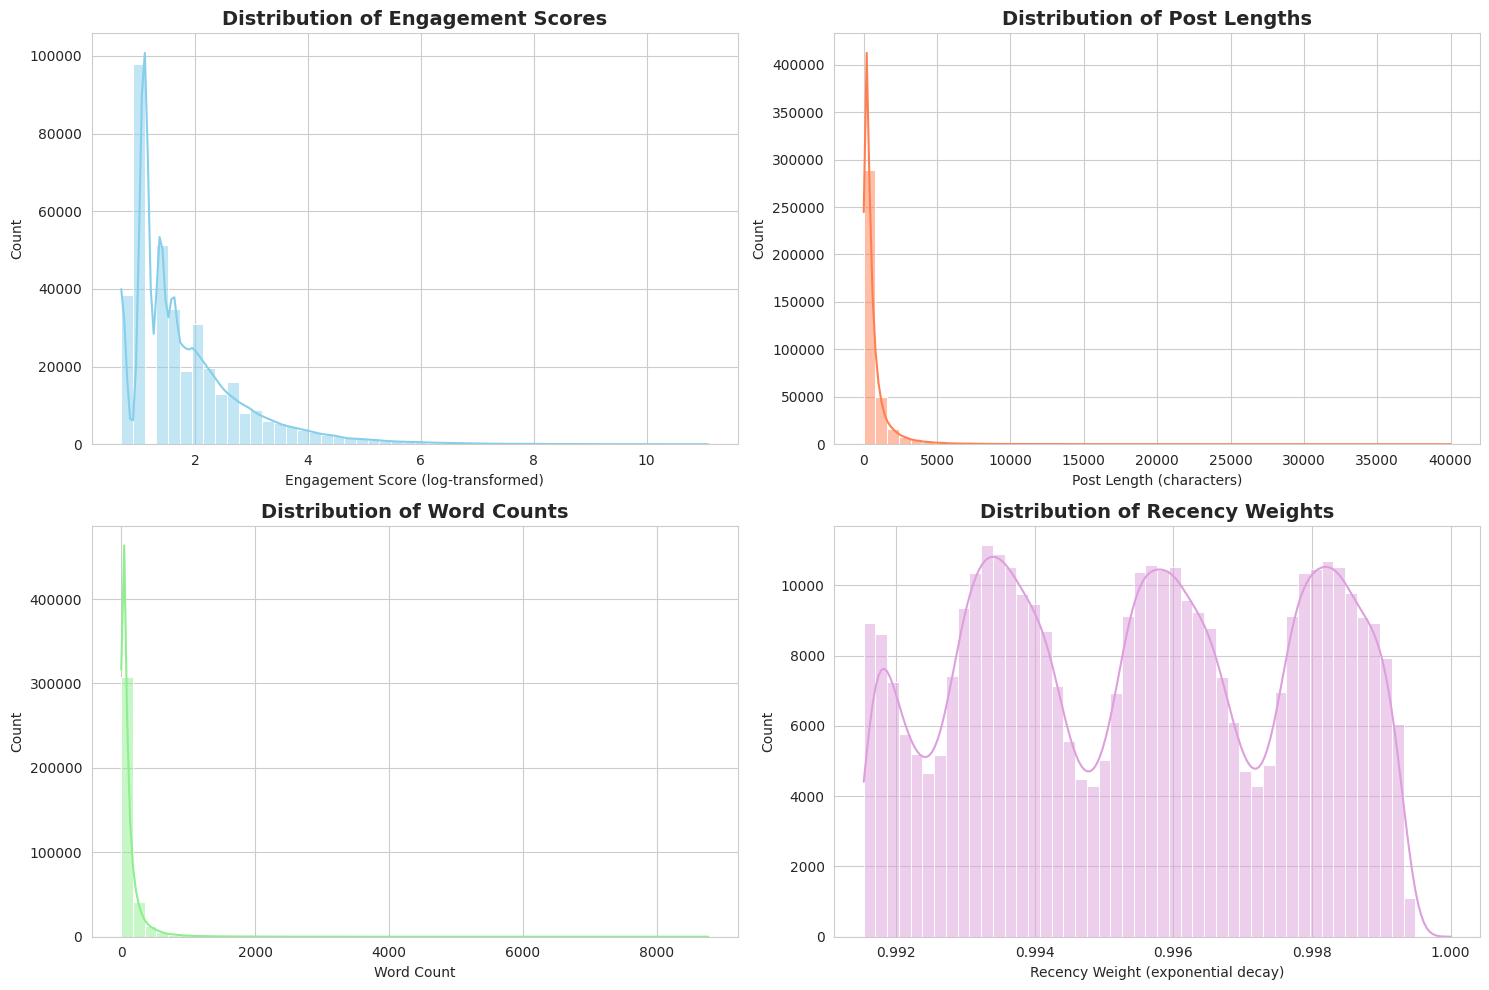

In [20]:
# Visualizations BEFORE Training

# 1. Distribution of engagement scores
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Engagement score distribution
sns.histplot(data=df, x='engagement_score', bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Engagement Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Engagement Score (log-transformed)')

# Post length distribution
sns.histplot(data=df, x='post_length', bins=50, kde=True, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Distribution of Post Lengths', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Post Length (characters)')

# Word count distribution
sns.histplot(data=df, x='word_count', bins=50, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Word Counts', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Word Count')

# Recency weight distribution  
sns.histplot(data=df, x='recency_weight', bins=50, kde=True, ax=axes[1, 1], color='plum')
axes[1, 1].set_title('Distribution of Recency Weights', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Recency Weight (exponential decay)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_140574/3959779416.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hour_counts.index, y=hour_counts.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_140574/3959779416.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[day_names[i] for i in day_counts.index], y=day_counts.values, ax=axes[1], palette='coolwarm')


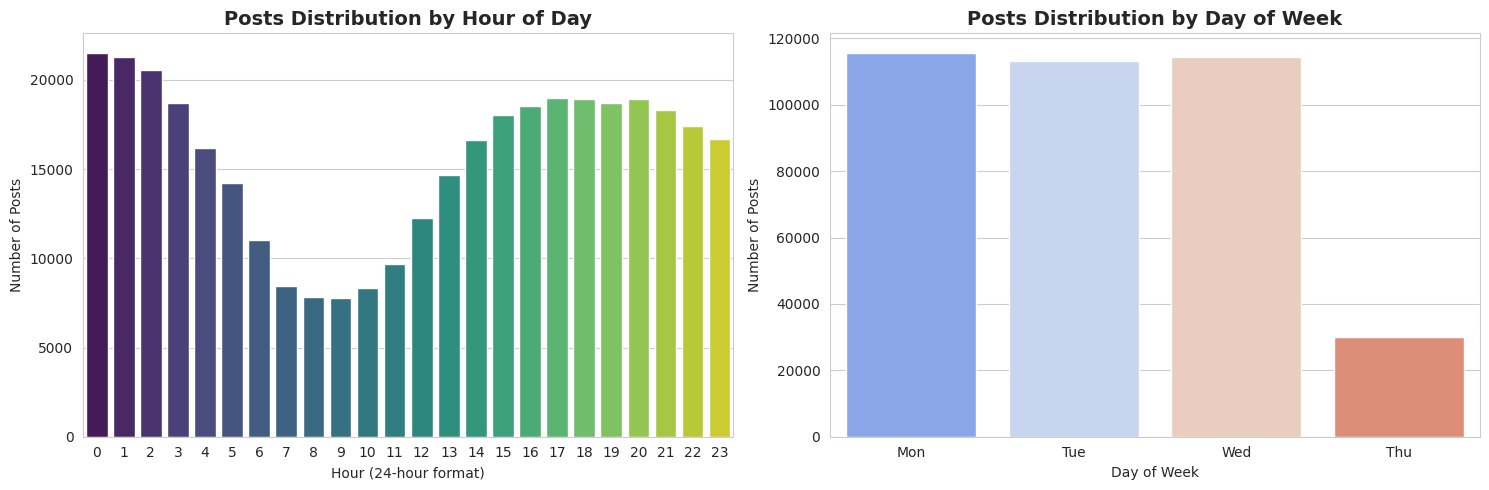

In [21]:
# 2. Temporal patterns visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Posts by hour of day
hour_counts = df['hour_posted'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Posts Distribution by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour (24-hour format)')
axes[0].set_ylabel('Number of Posts')

# Posts by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['day_of_week'].value_counts().sort_index()
sns.barplot(x=[day_names[i] for i in day_counts.index], y=day_counts.values, ax=axes[1], palette='coolwarm')
axes[1].set_title('Posts Distribution by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Posts')

plt.tight_layout()
plt.show()

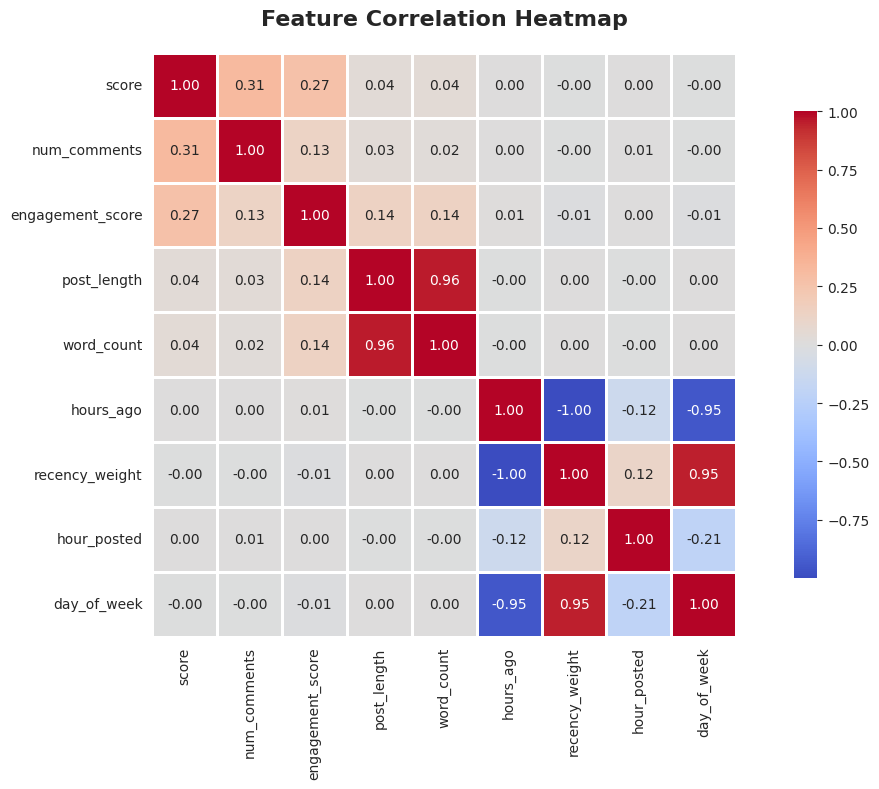

In [22]:
# 3. Feature correlation heatmap
numerical_features = ['score', 'num_comments', 'engagement_score', 'post_length', 
                      'word_count', 'hours_ago', 'recency_weight', 'hour_posted', 'day_of_week']

plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_140574/1207874388.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subreddits.values, y=top_subreddits.index, palette='rocket')


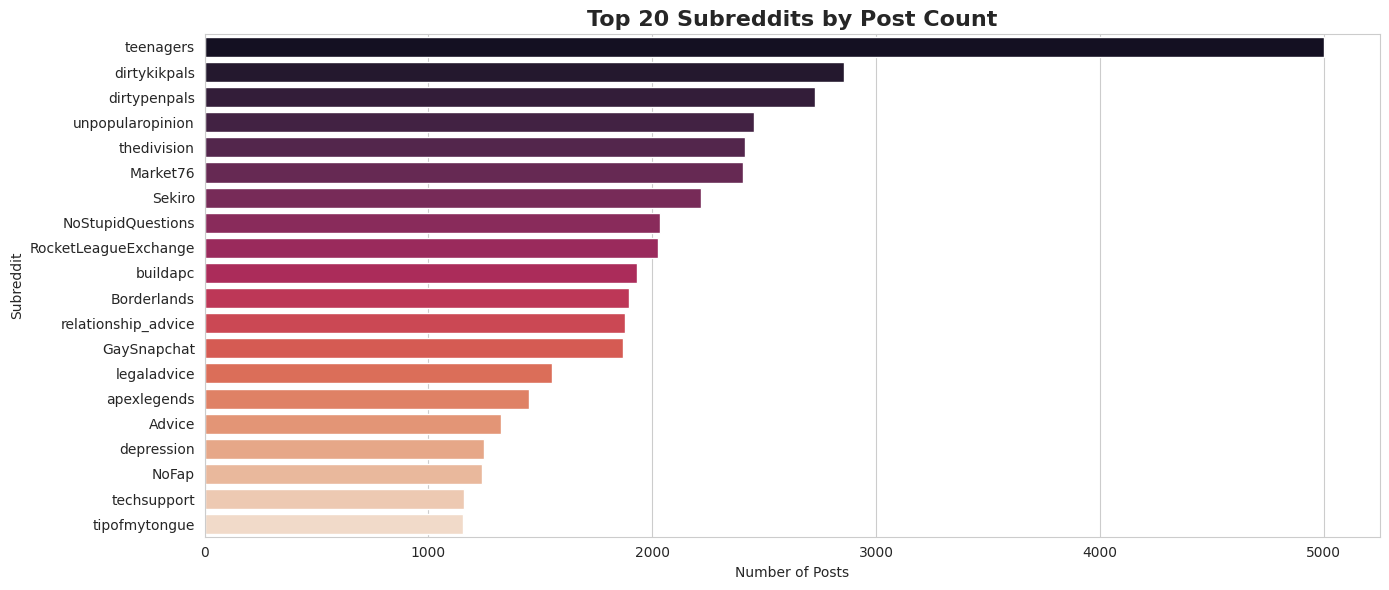

In [23]:
# 4. Top subreddits visualization
plt.figure(figsize=(14, 6))
top_subreddits = df['subreddit'].value_counts().head(20)
sns.barplot(x=top_subreddits.values, y=top_subreddits.index, palette='rocket')
plt.title('Top 20 Subreddits by Post Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Posts')
plt.ylabel('Subreddit')
plt.tight_layout()
plt.show()

In [24]:
import os
from sentence_transformers import SentenceTransformer

# Build combined text once (needed by the next cell)
df["full_text"] = (df["title"].fillna("") + " " + df["body"].fillna("")).str.strip()

# Check if embedding model already exists
model_path = "embedding_model"
if os.path.exists(model_path):
    print(f"Loading existing model from {model_path}...")
    embedding_model = SentenceTransformer(model_path)
else:
    print("Loading new model: paraphrase-MiniLM-L3-v2")
    embedding_model = SentenceTransformer("paraphrase-MiniLM-L3-v2")

chunk_size = 20000
all_embeddings = []

for i in range(0, len(df), chunk_size):
    batch_texts = df["full_text"].iloc[i:i + chunk_size].tolist()
    batch_embeddings = embedding_model.encode(
        batch_texts,
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")
    all_embeddings.append(batch_embeddings)

embeddings = np.vstack(all_embeddings)
df["text_embedding"] = list(embeddings)

/home/pujan-dev/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading existing model from embedding_model...


Batches: 100%|██████████| 107/107 [00:15<00:00,  7.03it/s]


In [25]:
# save the embedding_model
embedding_model.save("embedding_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.38it/s]


In [26]:
# enforcing categories and using kmeans to cluster the remaining posts

from sklearn.cluster import KMeans

# Build combined text (if not already created in previous cell)
if "full_text" not in df.columns:
    df["full_text"] = (df["title"].fillna("") + " " + df["body"].fillna("")).str.strip()

# 15 enforced keyword-based categories
ENFORCED_CATEGORIES  = {
    "gaming": [
        "fortnite", "apex", "league", "rocketleague", "dnd", "minecraft", "valorant", 
        "csgo", "cod", "call of duty", "pubg", "battlefield", "overwatch", "elden ring",
        "zelda", "skyrim", "assassins creed", "rpg", "moba", "gamer", "gaming", "steam",
        "xbox", "playstation", "nintendo", "switch", "fps", "esports", "multiplayer"
    ],
    "relationships": [
        "relationship", "dating", "love", "breakup", "marriage", "divorce", "boyfriend", 
        "girlfriend", "partner", "crush", "flirt", "romance", "friendship", "toxic", 
        "conflict", "communication", "jealousy", "advice", "trust", "feelings", "proposal"
    ],
    "career_jobs": [
        "job", "career", "resume", "interview", "application", "hiring", "promotion", 
        "salary", "internship", "work", "freelance", "contract", "office", "manager", 
        "boss", "colleague", "employment", "profession", "networking", "skills", "job search"
    ],
    "education": [
        "school", "college", "university", "exam", "study", "assignment", "homework", 
        "research", "grades", "test", "lecture", "professor", "degree", "class", 
        "course", "tuition", "scholarship", "study tips", "student", "learning"
    ],
    "finance": [
        "money", "stocks", "crypto", "budget", "finance", "saving", "investment", 
        "bitcoin", "ethereum", "loan", "debt", "bank", "credit", "tax", "retirement", 
        "portfolio", "dividends", "trading", "economy", "financial planning"
    ],
    "technology": [
        "tech", "programming", "buildapc", "software", "hardware", "ai", "machine learning",
        "coding", "python", "javascript", "java", "react", "node", "data science", 
        "cloud", "servers", "network", "security", "blockchain", "gadgets", "computers"
    ],
    "entertainment": [
        "movie", "tv", "series", "netflix", "disney", "hollywood", "bollywood", "music", 
        "concert", "show", "theater", "celebrity", "actors", "actress", "gaming", 
        "streaming", "youtube", "tiktok", "reviews", "reviews", "entertainment"
    ],
    "mental_health": [
        "depression", "anxiety", "stress", "mental health", "therapy", "counseling", 
        "self care", "mindfulness", "panic", "suicide", "help", "support", "PTSD", 
        "emotional", "meditation", "motivation", "overthinking", "burnout", "mental illness", "coping"
    ],
    "parenting_family": [
        "parent", "family", "kids", "children", "baby", "toddler", "adolescent", "school", 
        "homework", "education", "mom", "dad", "siblings", "grandparent", "household", 
        "childcare", "discipline", "pregnancy", "family time", "relationship"
    ],
    "health_fitness": [
        "exercise", "workout", "gym", "running", "diet", "nutrition", "weight loss", 
        "fitness", "cardio", "strength", "training", "yoga", "pilates", "health", "vitamins", 
        "supplements", "wellness", "endurance", "sports", "healthy"
    ],
    "travel": [
        "trip", "vacation", "tourism", "flight", "hotel", "backpacking", "road trip", 
        "adventure", "itinerary", "guide", "beach", "mountains", "travel tips", "visa", 
        "passport", "travel blog", "culture", "explore", "destination", "journey"
    ],
    "sports": [
        "football", "soccer", "basketball", "tennis", "cricket", "baseball", "hockey", 
        "olympics", "athletics", "golf", "rugby", "coach", "team", "match", "league", 
        "training", "tournament", "player", "score", "competition"
    ],
    "news_politics": [
        "news", "politics", "election", "government", "policy", "vote", "campaign", 
        "president", "prime minister", "congress", "senate", "political party", 
        "debate", "protest", "law", "bill", "diplomacy", "international", "political news", "current affairs"
    ],
    "food_cooking": [
        "recipe", "cook", "cooking", "baking", "meal", "restaurant", "ingredients", 
        "food", "dinner", "lunch", "breakfast", "healthy eating", "chef", "dessert", 
        "grill", "vegetarian", "vegan", "snack", "kitchen", "cuisine"
    ],
    "science": [
        "physics", "chemistry", "biology", "research", "experiment", "laboratory", 
        "space", "astronomy", "earth", "math", "quantum", "genetics", "technology", 
        "environment", "climate", "scientist", "study", "discovery", "innovation", "theory"
    ]
}

In [27]:


def assign_enforced_category(text: str):
    t = str(text).lower()
    for category, keywords in ENFORCED_CATEGORIES.items():
        if any(kw in t for kw in keywords):
            return category
    return None

# Enforced assignment

df["enforced_category"] = df["full_text"].apply(assign_enforced_category)


Posts with enforced categories: 293234
Posts without enforced categories: 80440


/tmp/ipykernel_140574/3659992447.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=enforced_counts.values, y=enforced_counts.index, palette='Set2')


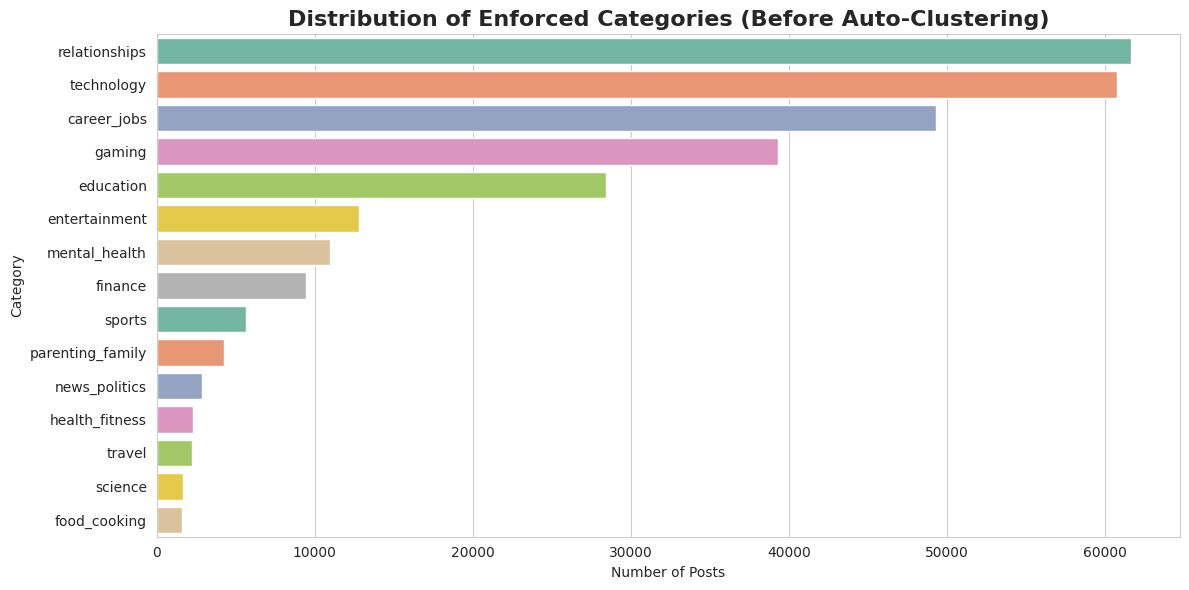

In [28]:
# Before clustering: Show enforced category distribution
enforced_counts = df['enforced_category'].value_counts()
print(f"Posts with enforced categories: {enforced_counts.sum()}")
print(f"Posts without enforced categories: {df['enforced_category'].isna().sum()}")

plt.figure(figsize=(12, 6))
sns.barplot(x=enforced_counts.values, y=enforced_counts.index, palette='Set2')
plt.title('Distribution of Enforced Categories (Before Auto-Clustering)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Posts')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [29]:

target_total_categories = 10
used_enforced = sorted(df["enforced_category"].dropna().unique().tolist())
used_enforced_count = len(used_enforced)

remaining_mask = df["enforced_category"].isna()
remaining_count = int(remaining_mask.sum())

n_auto = max(0, target_total_categories - used_enforced_count)

if n_auto > 0 and remaining_count > 0:
    n_clusters = min(n_auto, remaining_count)
    remaining_embeddings = embeddings[remaining_mask.to_numpy()]

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_ids = kmeans.fit_predict(remaining_embeddings)

    df.loc[remaining_mask, "auto_category"] = [f"auto_cluster_{i}" for i in cluster_ids]
else:
    df["auto_category"] = None



In [30]:
# During Training: Elbow method for KMeans
from sklearn.cluster import KMeans

print("DURING TRAINING: Finding optimal number of clusters...")

target_total_categories = 10
used_enforced = sorted(df["enforced_category"].dropna().unique().tolist())
used_enforced_count = len(used_enforced)

remaining_mask = df["enforced_category"].isna()
remaining_count = int(remaining_mask.sum())

n_auto = max(0, target_total_categories - used_enforced_count)

if n_auto > 0 and remaining_count > 0:
    n_clusters = min(n_auto, remaining_count)
    remaining_embeddings = embeddings[remaining_mask.to_numpy()]
    
    # Elbow method to visualize cluster quality
    max_k = min(10, remaining_count)
    inertias = []
    K_range = range(1, max_k + 1)
    
    print(f"Testing {max_k} different cluster sizes...")
    for k in K_range:
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans_temp.fit(remaining_embeddings)
        inertias.append(kmeans_temp.inertia_)
    
    # Plot elbow curve
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=list(K_range), y=inertias, marker='o', linewidth=2, markersize=8, color='dodgerblue')
    plt.axvline(x=n_clusters, color='red', linestyle='--', linewidth=2, label=f'Selected: {n_clusters} clusters')
    plt.title('KMeans Elbow Method: Finding Optimal Clusters', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
    plt.xticks(K_range)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Selected {n_clusters} auto-clusters (to complement {used_enforced_count} enforced categories)")
else:
    print("No auto-clustering needed")

DURING TRAINING: Finding optimal number of clusters...
No auto-clustering needed


In [31]:

df["final_category"] = df["enforced_category"].fillna(df["auto_category"]).fillna("uncategorized")

# Create user × category interaction matrix
interaction_matrix = df.pivot_table(
    index="author",
    columns="final_category",
    values="engagement_score",
    aggfunc="sum",
    fill_value=0.0,
)


/tmp/ipykernel_140574/3477846375.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=final_counts.values, y=final_counts.index, ax=axes[0], palette='mako')


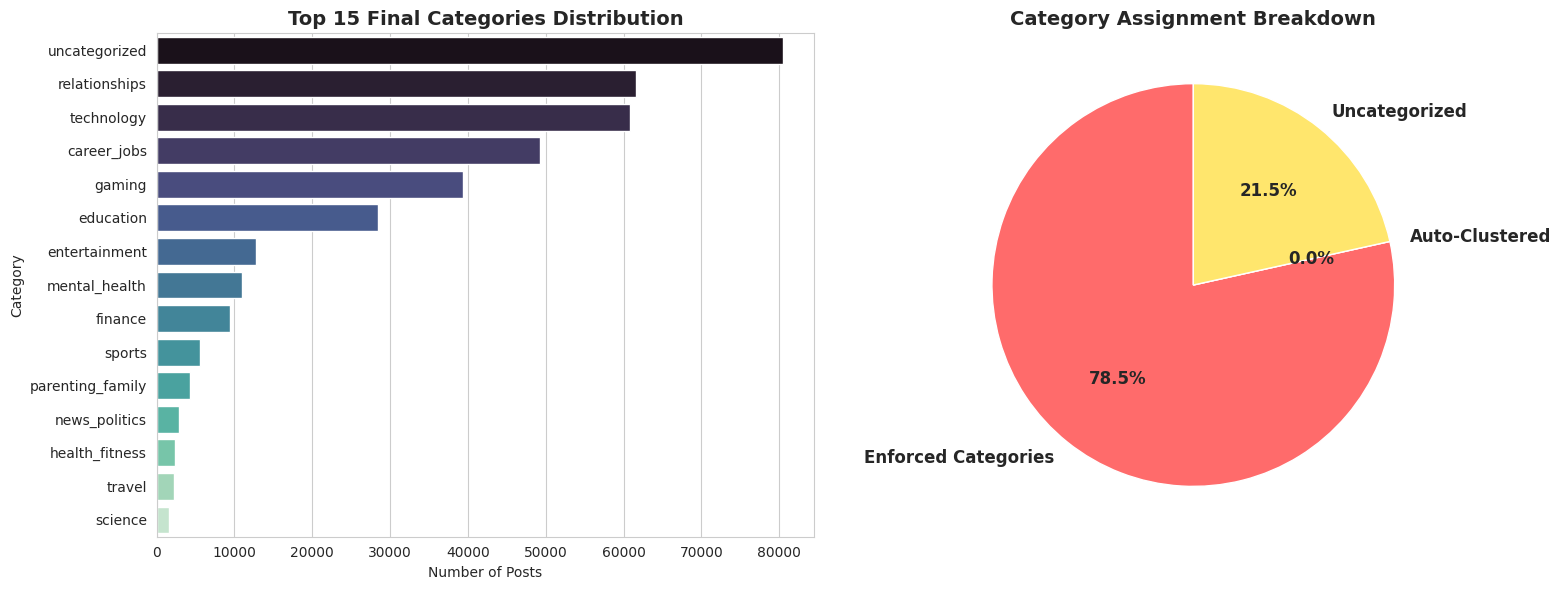


📊 Categorization Summary:
  • Enforced categories: 293234 posts
  • Auto-clustered: 0 posts
  • Uncategorized: 80440 posts
  • Total categories: 16


In [32]:
# After Clustering: Visualize Final Category Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Final category distribution
final_counts = df['final_category'].value_counts().head(15)
sns.barplot(x=final_counts.values, y=final_counts.index, ax=axes[0], palette='mako')
axes[0].set_title('Top 15 Final Categories Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Posts')
axes[0].set_ylabel('Category')

# Pie chart of category types
category_types = pd.Series({
    'Enforced Categories': df['enforced_category'].notna().sum(),
    'Auto-Clustered': df['auto_category'].notna().sum(),
    'Uncategorized': (df['final_category'] == 'uncategorized').sum()
})
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']
axes[1].pie(category_types.values, labels=category_types.index, autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Category Assignment Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Categorization Summary:")
print(f"  • Enforced categories: {df['enforced_category'].notna().sum()} posts")
print(f"  • Auto-clustered: {df['auto_category'].notna().sum()} posts")
print(f"  • Uncategorized: {(df['final_category'] == 'uncategorized').sum()} posts")
print(f"  • Total categories: {df['final_category'].nunique()}")

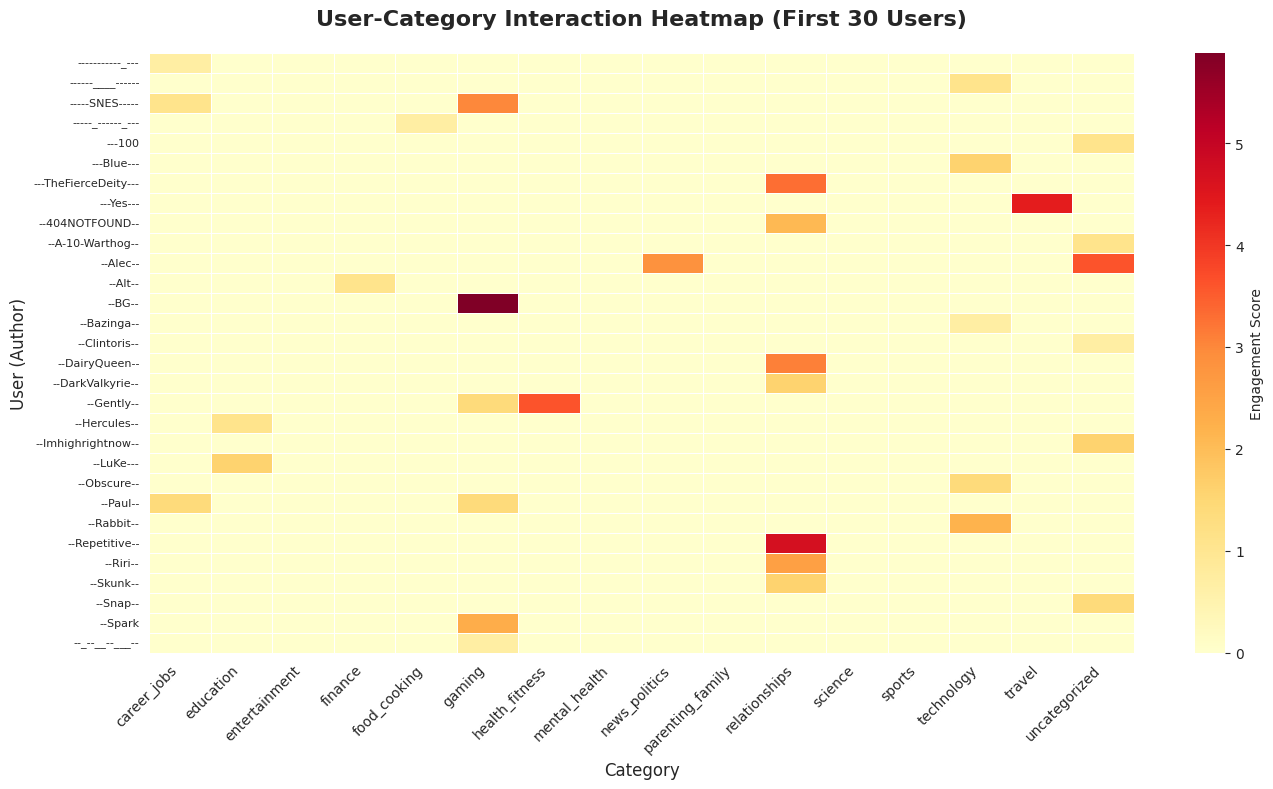

Interaction Matrix Shape: (270850, 16)
Total unique users: 270850
Total categories: 16


In [33]:
# User-Category Interaction Matrix Preview
plt.figure(figsize=(14, 8))

# Show a sample of the interaction matrix (first 30 users, all categories)
sample_size = min(30, len(interaction_matrix))
sample_matrix = interaction_matrix.head(sample_size)

sns.heatmap(sample_matrix, cmap='YlOrRd', cbar_kws={'label': 'Engagement Score'},
            linewidths=0.5, linecolor='white')
plt.title(f'User-Category Interaction Heatmap (First {sample_size} Users)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('User (Author)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Interaction Matrix Shape: {interaction_matrix.shape}")
print(f"Total unique users: {len(interaction_matrix)}")
print(f"Total categories: {len(interaction_matrix.columns)}")

/tmp/ipykernel_140574/693088025.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, y='final_category', x='engagement_score', palette='Set3')


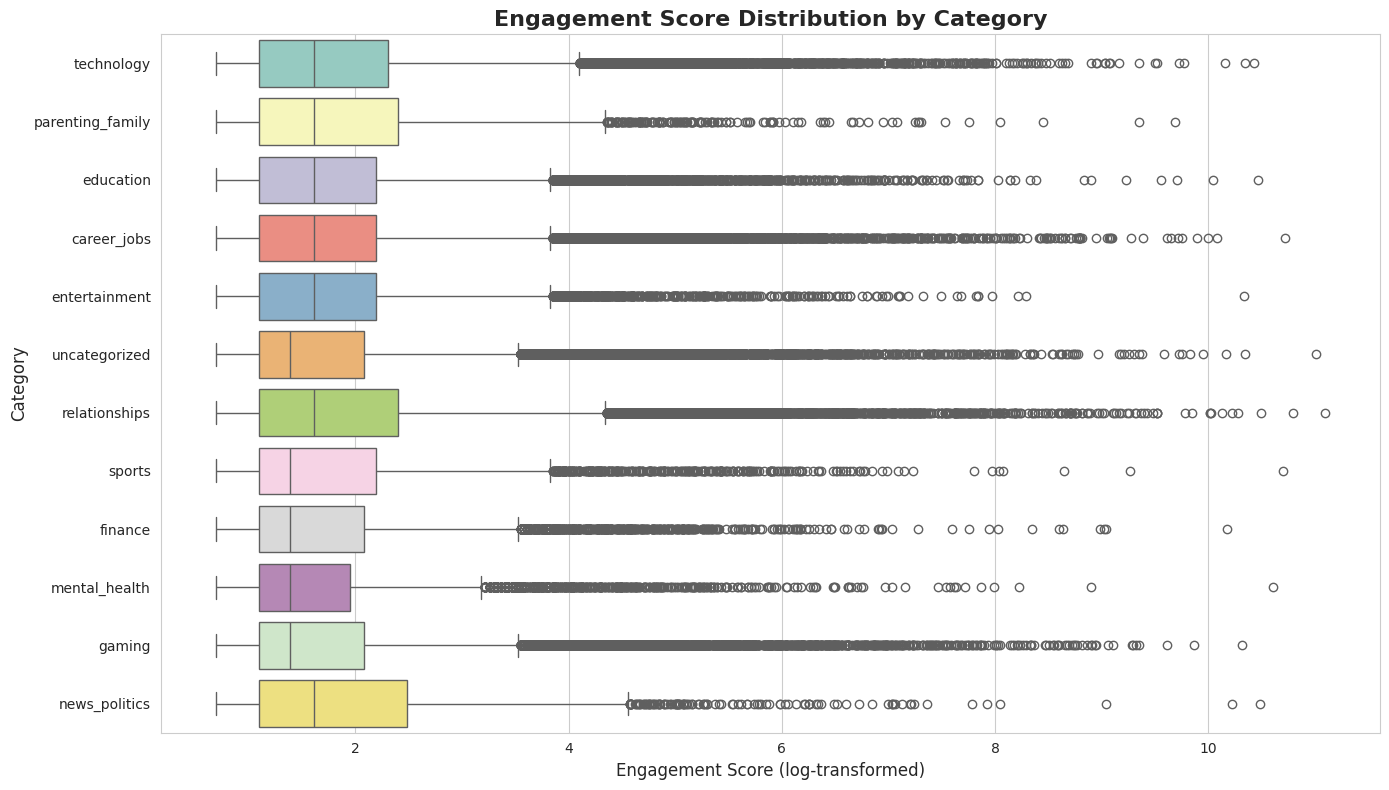


🏆 Top 10 Categories by Average Engagement:
  news_politics: 1.971
  relationships: 1.956
  parenting_family: 1.914
  career_jobs: 1.850
  education: 1.844
  food_cooking: 1.835
  technology: 1.832
  sports: 1.813
  entertainment: 1.796
  science: 1.794


In [34]:
# Engagement Score by Category (Box Plot)
plt.figure(figsize=(14, 8))

# Get top categories for clearer visualization
top_categories = df['final_category'].value_counts().head(12).index
df_top = df[df['final_category'].isin(top_categories)]

sns.boxplot(data=df_top, y='final_category', x='engagement_score', palette='Set3')
plt.title('Engagement Score Distribution by Category', fontsize=16, fontweight='bold')
plt.xlabel('Engagement Score (log-transformed)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

# Show mean engagement by category
mean_engagement = df.groupby('final_category')['engagement_score'].mean().sort_values(ascending=False).head(10)
print("\n🏆 Top 10 Categories by Average Engagement:")
for cat, score in mean_engagement.items():
    print(f"  {cat}: {score:.3f}")

Creating pairplot of key features (this may take a moment)...


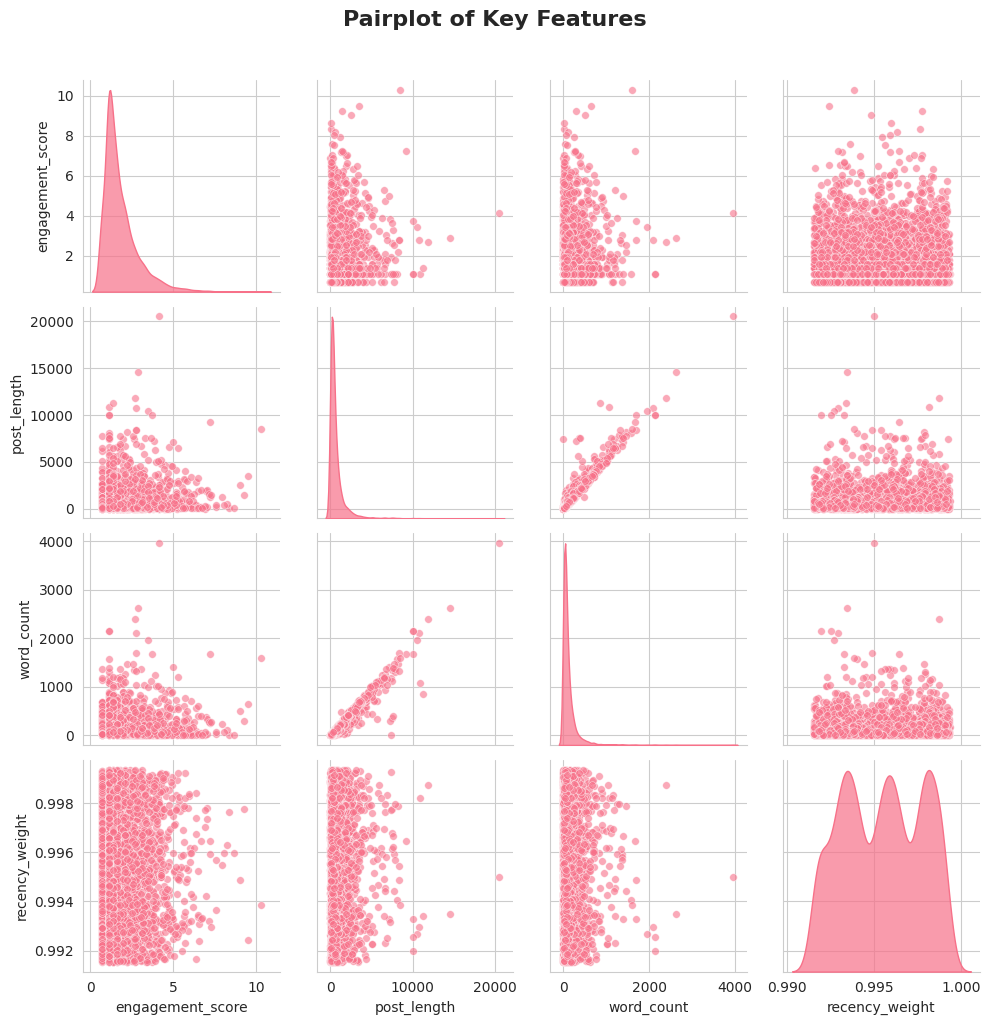

✓ All visualizations complete!


In [35]:
# Advanced: Pairplot of key numerical features
print("Creating pairplot of key features (this may take a moment)...")

# Sample data for faster plotting
sample_df = df.sample(n=min(5000, len(df)), random_state=42)
features_for_pairplot = ['engagement_score', 'post_length', 'word_count', 'recency_weight']

sns.pairplot(sample_df[features_for_pairplot], 
             diag_kind='kde', 
             plot_kws={'alpha': 0.6, 's': 30},
             diag_kws={'alpha': 0.7})
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ All visualizations complete!")

In [36]:

# Save both outputs to pickle
processed_path = "processed_posts.pkl"
matrix_path = "user_category_interaction_matrix.pkl"

df.to_pickle(processed_path)
interaction_matrix.to_pickle(matrix_path)



In [37]:
print("Processed DataFrame shape:", df.shape)
print("Interaction matrix shape:", interaction_matrix.shape)
print("Final category count:", df["final_category"].nunique())
print("Saved:", processed_path)
print("Saved:", matrix_path)
print(df["final_category"].value_counts().head(20))

Processed DataFrame shape: (373674, 21)
Interaction matrix shape: (270850, 16)
Final category count: 16
Saved: processed_posts.pkl
Saved: user_category_interaction_matrix.pkl
final_category
uncategorized       80440
relationships       61639
technology          60766
career_jobs         49317
gaming              39315
education           28438
entertainment       12827
mental_health       10945
finance              9449
sports               5622
parenting_family     4252
news_politics        2888
health_fitness       2304
travel               2244
science              1645
food_cooking         1583
Name: count, dtype: int64


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373674 entries, 0 to 499999
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   id                 373674 non-null  object        
 1   author             373674 non-null  object        
 2   subreddit          373674 non-null  object        
 3   title              373674 non-null  object        
 4   body               373674 non-null  object        
 5   score              373674 non-null  int64         
 6   num_comments       373674 non-null  int64         
 7   created_utc        373674 non-null  datetime64[ns]
 8   engagement_score   373674 non-null  float64       
 9   post_length        373674 non-null  int64         
 10  word_count         373674 non-null  int64         
 11  hours_ago          373674 non-null  float64       
 12  recency_weight     373674 non-null  float64       
 13  hour_posted        373674 non-null  int32        

In [39]:
cols_to_drop = ["author", "hours_ago", "user_post_id", "auto_category", "enforced_category"]
df = df.drop(columns=cols_to_drop)

In [40]:
embeddings = np.array(embeddings).astype("float32")

In [41]:
import faiss
# 4. Create FAISS index
dimension = embeddings.shape[1]  # 384
index = faiss.IndexFlatL2(dimension)


In [42]:
# 5. Add embeddings to FAISS
index.add(embeddings)

# 6. Save FAISS index
faiss.write_index(index, "reddit_posts.faiss")

In [43]:
embedding_model = SentenceTransformer("paraphrase-MiniLM-L3-v2")
query = "transformer model released"
query_vector = embedding_model.encode([query]).astype("float32")

D, I = index.search(query_vector, k=10)
print(I)  # indices of top 10 similar posts

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 1000.74it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L3-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[[357989 172226 343112  21109  91035  88899 372941  21608  71416 306903]]


In [44]:
# POST_DB Schema:
post_db_schema = {
    "post_id": "string (unique subreddit post ID)",
    "subreddit": "string (original subreddit, e.g., 'technology')",
    "title": "string (post title)",
    "body": "string (cleaned post content)",
    "score": "int (upvotes - downvotes)",
    "num_comments": "int (number of comments)",
    "created_utc": "datetime (when post was created)",
    "engagement_score": "float (log-transformed score for weighting)",
    "post_length": "int (character count of body)",
    "word_count": "int (word count)",
    "hour_posted": "int (0-23, hour of day)",
    "day_of_week": "int (0-6, Monday=0)",
    "recency_weight": "float (exponential decay based on age)",
    "final_category": "string (gaming|relationships|career_jobs|...|uncategorized)",
    "full_text": "string (title + body combined)",
    "text_embedding": "ndarray[384] (dense vector from SentenceTransformer)"
}

print("POST_DB has", len(df), "posts")
print("POST_DB columns:", df.columns.tolist())
print("\nSample post:\n", df.iloc[0])


POST_DB has 373674 posts
POST_DB columns: ['id', 'subreddit', 'title', 'body', 'score', 'num_comments', 'created_utc', 'engagement_score', 'post_length', 'word_count', 'recency_weight', 'hour_posted', 'day_of_week', 'full_text', 'text_embedding', 'final_category']

Sample post:
 id                                                             b7um2n
subreddit                                                    FORTnITE
title                                         Daily Llama 31/Mar/2019
body                Weapon Llama 1 @ 200 vBucks [Description Unkno...
score                                                               0
num_comments                                                        8
created_utc                                       2019-04-01 00:00:00
engagement_score                                             0.693147
post_length                                                        85
word_count                                                         15
recency_weight      

In [45]:
# USER DATABASE STRUCTURE


user_db_example = [
    {
        "user_id": "456",
        "username": "pujan_dev",
        "profile": {
            "created_at": "2024-01-15T10:30:00Z",
            "preferences": {
                "preferred_categories": ["technology", "science"],  # User's stated interests
                "language": "en",
                "content_filter": "no_nsfw"
            }
        },
        "interaction_history": [
            {
                "interaction_id": "int_123",
                "post_id": "post_789",  # References POST_DB
                "post_category": "technology",
                "action": "upvote",  # upvote | downvote | view | comment | share
                "dwell_time_seconds": 120,  # Time spent viewing
                "timestamp": "2024-06-10T15:30:00Z",
                "engagement_value": 1.0  # Derived: upvote=1.0, view=0.3, downvote=-1.0, etc.
            },
            {
                "interaction_id": "int_124",
                "post_id": "post_790",
                "post_category": "science",
                "action": "view",
                "dwell_time_seconds": 45,
                "timestamp": "2024-06-10T16:00:00Z",
                "engagement_value": 0.3
            }
        ],
        "category_preferences": {  # Derived from interaction_matrix
            "technology": 2.5,
            "science": 1.2,
            "gaming": 0.1
        },
        "stats": {
            "total_interactions": 2,
            "avg_dwell_time": 82.5,
            "last_active": "2024-06-10T16:00:00Z"
        }
    },
    {
        "user_id": "789",
        "username": "alice_smith",
        "profile": {
            "created_at": "2024-05-20T09:00:00Z",
            "preferences": {
                "preferred_categories": ["health", "fitness"],
                "language": "en",
                "content_filter": "all"
            }
        },
        "interaction_history": [
            {
                "interaction_id": "int_200",
                "post_id": "post_456",
                "post_category": "health",
                "action": "upvote",
                "dwell_time_seconds": 90,
                "timestamp": "2024-06-12T10:15:00Z",
                "engagement_value": 1.0
            }
        ],
        "category_preferences": {
            "health": 3.5,
            "fitness": 2.8
        },
        "stats": {
            "total_interactions": 1,
            "avg_dwell_time": 90,
            "last_active": "2024-06-12T10:15:00Z"
        }
    }
]

print("USER_DB structure defined with", len(user_db_example), "example users")


USER_DB structure defined with 2 example users


In [46]:
# SAVE MODEL ARTIFACTS (what to persist)
import os
import pickle

def save_model_artifacts():
    """Save all model components for inference without retraining."""
    
    artifacts = {
        # 1. Embedding Model (transformer weights)
        "embedding_model_path": "embedding_model/",
        
        # 2. FAISS Index (semantic search structure)
        "faiss_index_path": "reddit_posts.faiss",
        
        # 3. Processed Posts DataFrame (metadata + embeddings)
        "posts_df_path": "processed_posts.pkl",
        
        # 4. User-Category Interaction Matrix (for collab filtering)
        "interaction_matrix_path": "user_category_interaction_matrix.pkl",
    }
    
    print("MODEL ARTIFACTS TO SAVE:")
    for name, path in artifacts.items():
        if os.path.exists(path):
            size = os.path.getsize(path) if os.path.isfile(path) else "directory"
            print(f"  {name}: {path} ({size})")
        else:
            print(f"  {name}: {path} (not yet saved)")
    
    return artifacts

artifacts = save_model_artifacts()

print("\nThese files are already saved (check earlier cells)")
print(" Keep them in the MODEL/ directory for the backend to load")


MODEL ARTIFACTS TO SAVE:
  embedding_model_path: embedding_model/ (directory)
  faiss_index_path: reddit_posts.faiss (573963309)
  posts_df_path: processed_posts.pkl (1207760554)
  interaction_matrix_path: user_category_interaction_matrix.pkl (38485253)

These files are already saved (check earlier cells)
 Keep them in the MODEL/ directory for the backend to load


In [47]:
# LOAD ARTIFACTS FOR BACKEND INFERENCE

def load_model_artifacts():
    """Load all pre-trained artifacts for inference."""
    from sentence_transformers import SentenceTransformer
    import pickle
    
    print("Loading model artifacts...")
    
    # 1. Load embedding model
    embedding_model = SentenceTransformer("embedding_model")
    print("✓ Loaded embedding model")
    
    # 2. Load FAISS index
    faiss_index = faiss.read_index("reddit_posts.faiss")
    print(f"✓ Loaded FAISS index ({faiss_index.ntotal} posts)")
    
    # 3. Load posts DataFrame (contains metadata)
    with open("processed_posts.pkl", "rb") as f:
        posts_df = pickle.load(f)
    print(f"✓ Loaded posts DataFrame ({len(posts_df)} posts)")
    
    # 4. Load interaction matrix
    with open("user_category_interaction_matrix.pkl", "rb") as f:
        interaction_matrix = pickle.load(f)
    print(f"✓ Loaded interaction matrix ({interaction_matrix.shape})")
    
    return {
        "embedding_model": embedding_model,
        "faiss_index": faiss_index,
        "posts_df": posts_df,
        "interaction_matrix": interaction_matrix
    }

# Load artifacts (only if files exist)
if os.path.exists("embedding_model") and os.path.exists("reddit_posts.faiss"):
    artifacts_loaded = load_model_artifacts()
    embedding_model = artifacts_loaded["embedding_model"]
    faiss_index = artifacts_loaded["faiss_index"]
    posts_df = artifacts_loaded["posts_df"]
    interaction_matrix = artifacts_loaded["interaction_matrix"]
else:
    print("⚠ Model artifacts not found. Run earlier cells to generate them.")
    artifacts_loaded = None


Loading model artifacts...


Loading weights: 100%|██████████| 55/55 [00:00<00:00, 845.20it/s, Materializing param=pooler.dense.weight]                              


✓ Loaded embedding model
✓ Loaded FAISS index (373674 posts)
✓ Loaded posts DataFrame (373674 posts)
✓ Loaded interaction matrix ((270850, 16))
